In [25]:
import numpy as np
import pandas as pd
import corner
import matplotlib.pyplot as plt

In [26]:
def log_likelihood(x_pc,y_pc,f,alpha,mu_x,mu_y,sigma_x,sigma_y):
    if f < 0 or f > 1 or sigma_x <= 0 or sigma_y <= 0:
        return -np.inf

    range_x=10000
    range_y=10000

    # mu_x and mu_y are the center in the original X_pc/Y_pc frame.
    dx=x_pc-mu_x
    dy=y_pc-mu_y
    x1=dx*np.cos(alpha)+dy*np.sin(alpha)
    y1=dy*np.cos(alpha)-dx*np.sin(alpha)

    log_gauss=-np.log(2*np.pi)-np.log(sigma_x)-np.log(sigma_y)-0.5*(x1**2/sigma_x**2+y1**2/sigma_y**2)
    log_bg=-np.log(range_x*range_y)

    if f == 0:
        return len(x_pc)*log_bg
    if f == 1:
        return np.sum(log_gauss)

    single_logp=np.logaddexp(np.log(f)+log_gauss,np.log1p(-f)+log_bg)
    return np.sum(single_logp)

In [27]:
def metropolis_full_param(
    x_pc, y_pc,
    n_samples=50000,
    f_init=0.5, alpha_init=0,
    mu_x_init=0, mu_y_init=0,
    sig_x_init=1, sig_y_init=1,
    step_f=0.02, step_alpha=0.3,
    step_mu_x=5, step_mu_y=5,
    step_sig_x=5, step_sig_y=5,
    clip=10000,
    name=""
):
    count_accepted = 0
    count_proposed = 0
    # 链每行：[f, alpha, mu_x, mu_y, sig_x, sig_y, logL]
    n_col = 7
    chain = np.zeros((n_samples, n_col))

    f0 = f_init
    a0 = alpha_init
    mx0 = mu_x_init
    my0 = mu_y_init
    sx0 = sig_x_init
    sy0 = sig_y_init
    logL0 = log_likelihood(x_pc, y_pc, f0, a0, mx0, my0, sx0, sy0)
    chain[0] = [f0, a0, mx0, my0, sx0, sy0, logL0]

    param_steps = [step_f, step_alpha, step_mu_x, step_mu_y, step_sig_x, step_sig_y]

    for i in range(1, n_samples):
        f_curr, a_curr, mx_curr, my_curr, sx_curr, sy_curr, logL_curr = chain[i-1]
        curr_params = [f_curr, a_curr, mx_curr, my_curr, sx_curr, sy_curr]
        new_params = curr_params.copy()
        accept = False

        for pid in range(6):
            step = param_steps[pid]
            prop_val = np.random.normal(new_params[pid], step)
            temp_params = new_params.copy()
            temp_params[pid] = prop_val

            f_p, a_p, mx_p, my_p, sx_p, sy_p = temp_params
            if f_p < 0 or f_p > 1 or sx_p < 20 or sy_p < 20 or sx_p > 1200 or sy_p > 1200 or a_p < 0 or a_p > np.pi:
                continue

            count_proposed += 1
            logL_prop = log_likelihood(x_pc, y_pc, f_p, a_p, mx_p, my_p, sx_p, sy_p)
            log_ratio = logL_prop - logL_curr
            
            if np.log(np.random.rand()) < log_ratio:
                new_params = temp_params
                logL_curr = logL_prop
                accept = True
                count_accepted += 1

        f_new, a_new, mx_new, my_new, sx_new, sy_new = new_params
        chain[i] = [f_new, a_new, mx_new, my_new, sx_new, sy_new, logL_curr]

    burn_in = chain[clip:]
    print(f"总采样 {n_samples}, 有效proposal {count_proposed}, 接受次数 {count_accepted}, 接受率 {count_accepted/count_proposed:.3f}")
    df_chain = pd.DataFrame(burn_in, columns=["f","alpha","mu_x","mu_y","sig_x","sig_y","logL"])
    df_chain.to_csv(f"{name}_mcmc.csv", index=False)
    return burn_in


In [28]:
def plot_corner(samples):
    fig = corner.corner(
        samples[:, [0, 1, 2, 3, 4, 5]],
        labels=[
            r"$f$",
            r"$\alpha$",
            r"$\mu_x$ (pc)",
            r"$\mu_y$ (pc)",
            r"$\sigma_x$ (pc)",
            r"$\sigma_y$ (pc)"
        ],
        show_titles=True,
        title_fmt=".3f",
        quantiles=[0.16, 0.5, 0.84],
        levels=(0.16, 0.5, 0.84),
        color="royalblue",
        fill_contours=True
    )
    plt.show()
    return fig


In [29]:
def main(data):
    df = pd.read_csv(data)
    x_pc = df["X_pc"].values
    y_pc = df["Y_pc"].values

    samples = metropolis_full_param(
        x_pc=x_pc,
        y_pc=y_pc,
        n_samples=20000,
        f_init=0.1,
        alpha_init=np.pi/4,
        mu_x_init=0,
        mu_y_init=0,
        sig_x_init=100,
        sig_y_init=100,
        step_f=0.05,
        step_alpha=0.05,
        step_mu_x=60,
        step_mu_y=60,
        step_sig_x=40,
        step_sig_y=40,
        clip=1000,
        name=data.split("/")[-1].split(".")[0]
    )

    param_mean = np.mean(samples, axis=0)[:6]
    param_std = np.std(samples, axis=0)[:6]
    names = ["f", "alpha", "mu_x", "mu_y", "sig_x", "sig_y"]
    print("==== 参数后验均值±标准差 ====")
    for n, m, s in zip(names, param_mean, param_std):
        print(f"{n:6s}: mean={m:.3f}, std={s:.3f}")

    plot_corner(samples)


总采样 20000, 有效proposal 119644, 接受次数 46692, 接受率 0.390
==== 参数后验均值±标准差 ====
f     : mean=0.106, std=0.006
alpha : mean=0.241, std=0.043
mu_x  : mean=20.989, std=14.131
mu_y  : mean=23.551, std=26.857
sig_x : mean=207.847, std=10.343
sig_y : mean=435.004, std=22.357


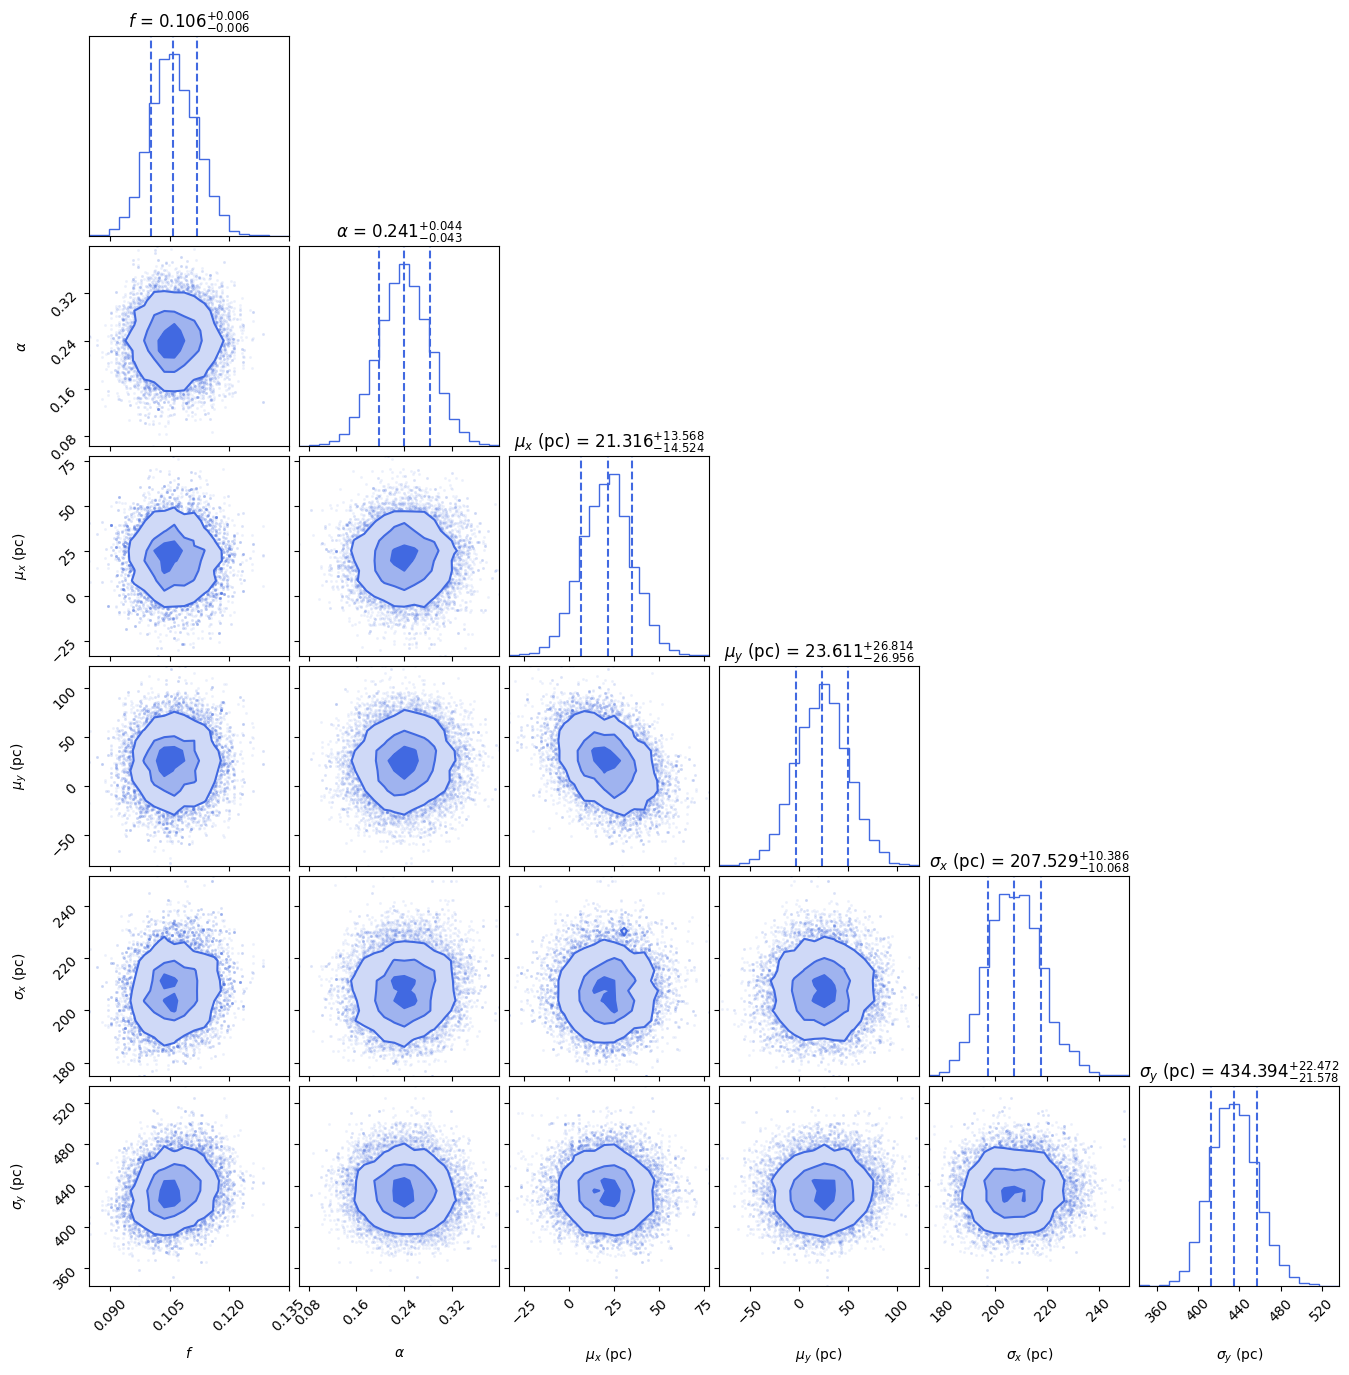

In [30]:
main("data\Dwarfs\Dwarf_03.csv")